# This is to deal only with the ID = 0 File for finding NSC

In [1]:
import numpy as np
import pandas, os, astropy, scipy, math
import matplotlib.pyplot as plt
import sklearn
from photutils.aperture import CircularAperture, SkyCircularAperture, aperture_photometry, EllipticalAperture, SkyEllipticalAperture
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization import simple_norm
from astropy.wcs.utils import pixel_to_skycoord
import astropy.io.fits as fits
from reproject import reproject_interp
import img_scale
from mpl_toolkits.axes_grid1 import Divider, Size
from astropy.cosmology import FlatLambdaCDM 
from astropy.wcs.utils import proj_plane_pixel_scales

In [2]:
# Writing a function to calculate the magnitude difference bewteen the 2 largest objects
def max_mag_diff(magar):
    lstmag = magar.tolist()
    sortedlstmag = sorted(lstmag)
    magdif1 = sortedlstmag[0] - sortedlstmag[1]
    print(" The magnitude difference between the brightest and 2nd brightest object is {}".format(magdif1))

In [4]:
galcenx0 = 2183.5457595291505
galceny0 = 3244.685526523298
cut_cat0 = pandas.read_csv('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/0_SMDG1048131+115807_cut_catalog.csv')
cut_cat0.columns

Index(['Unnamed: 0', 'ext', 'chip', 'xc', 'yc', 'chi', 'snr', 'sharpness',
       'roundness', 'pa', 'crowding', 'objtype', 'F606W_count', 'F606W_sky',
       'F606W_count_rate', 'F606W_count_rate_uncer', 'F606W_mag_vega',
       'F606W_mag_ubvri', 'F606W_mag_uncer', 'F606W_chi', 'F606W_snr',
       'F606W_sharpness', 'F606W_roundness', 'F606W_crowding', 'F606W_flag',
       'F814W_count', 'F814W_sky', 'F814W_count_rate',
       'F814W_count_rate_uncer', 'F814W_mag_vega', 'F814W_mag_ubvri',
       'F814W_mag_uncer', 'F814W_chi', 'F814W_snr', 'F814W_sharpness',
       'F814W_roundness', 'F814W_crowding', 'F814W_flag', 'aper_4', 'aper_8',
       'newconcent'],
      dtype='object')

In [5]:
# Define cuts that we are using(comment out this cell to get the original data)
use_cat = cut_cat0

max_mag = 35.  # Maxmum mag (Telescope cut)
snr_thresh = 3.  # For nearby, 5
# crowd_thresh = 0.5 #[mag], Normal cut  
# sharp_thresh = 0.25 #Normal cut  defraction spikes
# round_thresh = 3.  #Weak constraint (elongated)
flag_thresh = np.array([0, 2])
flag_label = np.array(['Good', 'Edge', 'Bad,Sat-pixel', 'Edge+badpixel'])

## Instrumental VEGAMAG magnitude cut
print(f"Total dolphot catalogue length: {len(use_cat)}")
print(f"Require: mag < {max_mag}")
condition = (use_cat.iloc[:,16] < max_mag) & (use_cat.iloc[:,29] < max_mag)
sub_dolcut_cat = use_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## SNR cut
print(f"Require: S/N > {snr_thresh}.")
condition = (sub_dolcut_cat.iloc[:,20] > snr_thresh) & (sub_dolcut_cat.iloc[:,33] > snr_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Object Type cut
print("Remove sources that are not type point-like.")
condition = (sub_dolcut_cat.iloc[:,11] <= 2)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

## Photometry quality flag cut
print("Remove sources that have flag= ", flag_thresh, "or", flag_label[flag_thresh])
condition = np.isin(sub_dolcut_cat.iloc[:,24], flag_thresh) & np.isin(sub_dolcut_cat.iloc[:,37], flag_thresh)
sub_dolcut_cat = sub_dolcut_cat[condition]
print(f"New catalogue length: {len(sub_dolcut_cat)}")

cut_cat0 = sub_dolcut_cat 

Total dolphot catalogue length: 96577
Require: mag < 35.0
New catalogue length: 96295
Require: S/N > 3.0.
New catalogue length: 3921
Remove sources that are not type point-like.
New catalogue length: 3770
Remove sources that have flag=  [0 2] or ['Good' 'Bad,Sat-pixel']
New catalogue length: 3727


In [88]:
#creating 2 numpy arrays that hold the xc and yc of each bright object
xcgal0 = cut_cat0['xc'].to_numpy()
ycgal0 = cut_cat0['yc'].to_numpy()
f606mag0 = cut_cat0['F606W_mag_vega'].to_numpy()
f814mag0 = cut_cat0['F814W_mag_vega'].to_numpy()

In [89]:
#calculating the distance from the centre of the galaxy for each bright object
distgal0 = np.sqrt((xcgal0 - galcenx0)**2 + (ycgal0 - galceny0)**2)


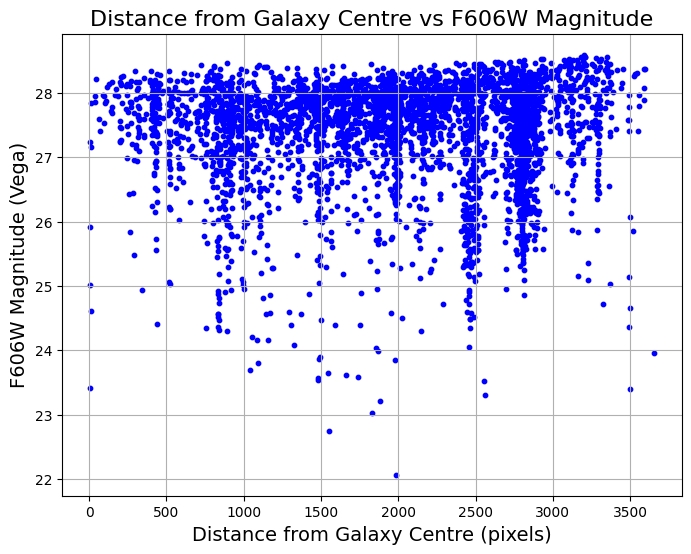

In [8]:
#plotting distance vs magnitude for F606W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal0, f606mag0, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F606W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F606W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

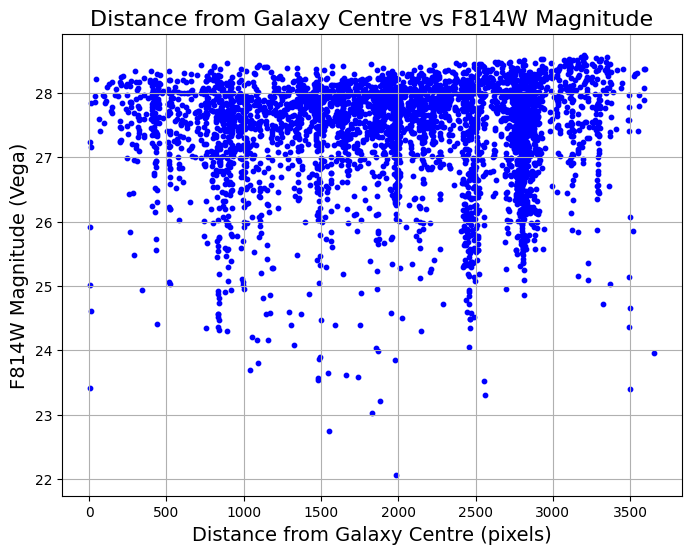

In [9]:
#plotting the distance vs magnitude for F814W filter
plt.figure(figsize=(8,6))
plt.scatter(distgal0, f606mag0, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

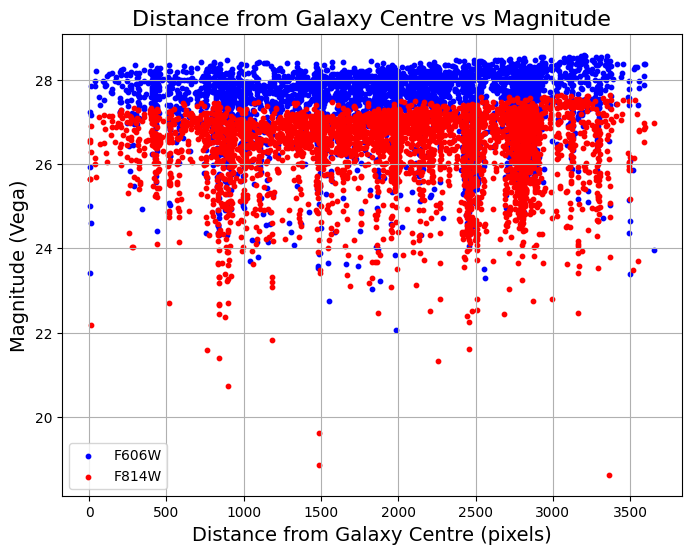

In [10]:
#plotting distance vs magnitude for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal0, f606mag0, color='blue', s=10, label='F606W')
plt.scatter(distgal0, f814mag0, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [11]:
# converting pixel in re(arcsec) to pixels
re_arcsec0 = 9.31

hdul0 = fits.open('/Users/ananthmugundhan/Coding/Research_work/Space_data/HST_cut2/ID_0_F814/MAST_2025-11-09T22_49_51.321Z/HST/jd5h07020_drc.fits')
if len(hdul0) > 1:
    hdr0 = hdul0[1].header
else:
    hdr0 = hdul0[0].header
wcs0 = WCS(hdr0)
pixel_scale_degrees0 = proj_plane_pixel_scales(wcs0)
scale_arcsec_per_pixel0 = pixel_scale_degrees0[0] * 3600
scale_pixel_per_arcsec0 = 1 / scale_arcsec_per_pixel0
re_pixels0 = re_arcsec0 * scale_pixel_per_arcsec0
print(re_pixels0)

186.2000000000001


In [12]:
#refining the bright object list to only include objects within re and finding the colour of the objects
distgal_re0 = distgal0[distgal0 <= re_pixels0]
f606mag_re0 = f606mag0[distgal0 <= re_pixels0]
f814mag_re0 = f814mag0[distgal0 <= re_pixels0]
color0 = f606mag_re0 - f814mag_re0 

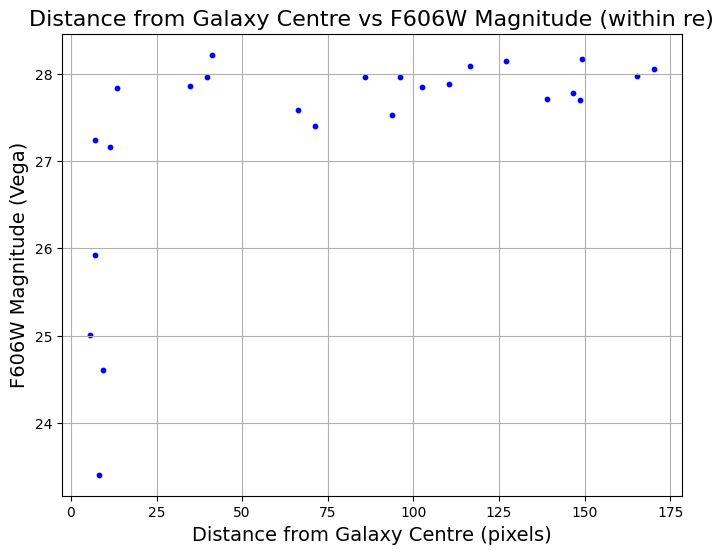

In [13]:
#plotting distance vs magnitude for f606w in re 
plt.figure(figsize=(8,6))
plt.scatter(distgal_re0, f606mag_re0, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F606W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('F606W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()  

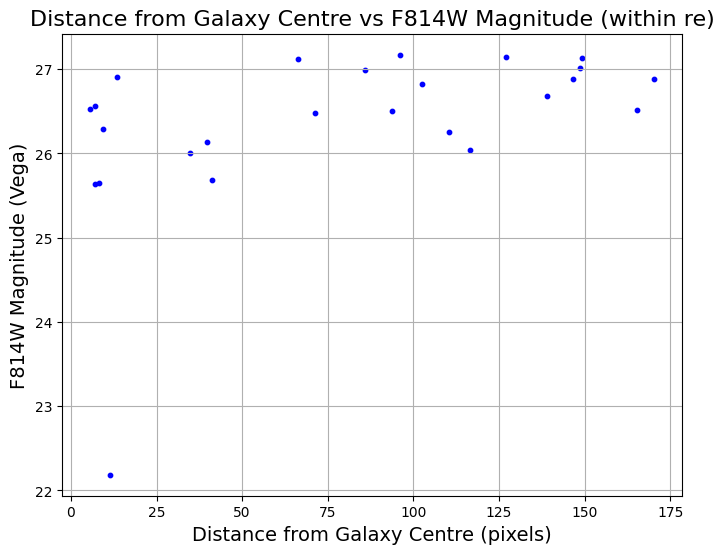

In [14]:
#plotting distance vs magnitude for f814w in re
plt.figure(figsize=(8,6))
plt.scatter(distgal_re0, f814mag_re0, color='blue', s=10)
plt.title('Distance from Galaxy Centre vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.grid()
plt.show()

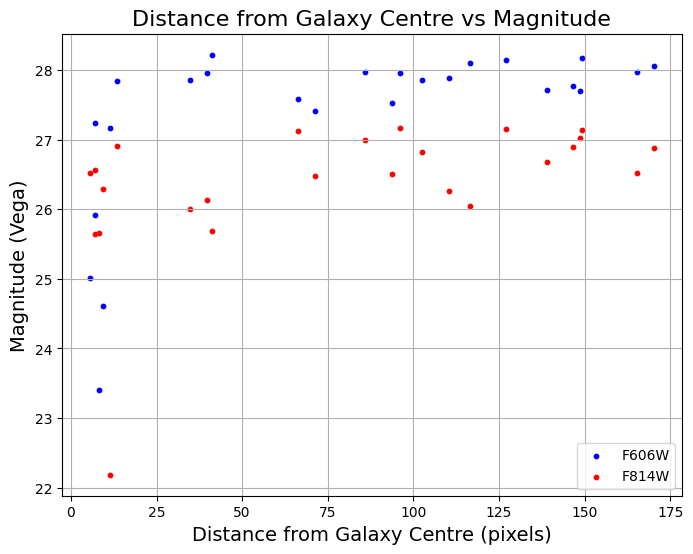

In [15]:
#plotting distance vs magnitude for the objects within re for both filters together
plt.figure(figsize=(8,6))
plt.scatter(distgal_re0, f606mag_re0, color='blue', s=10, label='F606W')
plt.scatter(distgal_re0, f814mag_re0, color='red', s=10, label='F814W')
plt.title('Distance from Galaxy Centre vs Magnitude', fontsize=16)
plt.xlabel('Distance from Galaxy Centre (pixels)', fontsize=14)
plt.ylabel('Magnitude (Vega)', fontsize=14)
plt.legend()
plt.grid()
plt.show()

In [16]:
# normalising the distance in terms of re
distgal_re0_n = distgal_re0/re_pixels0

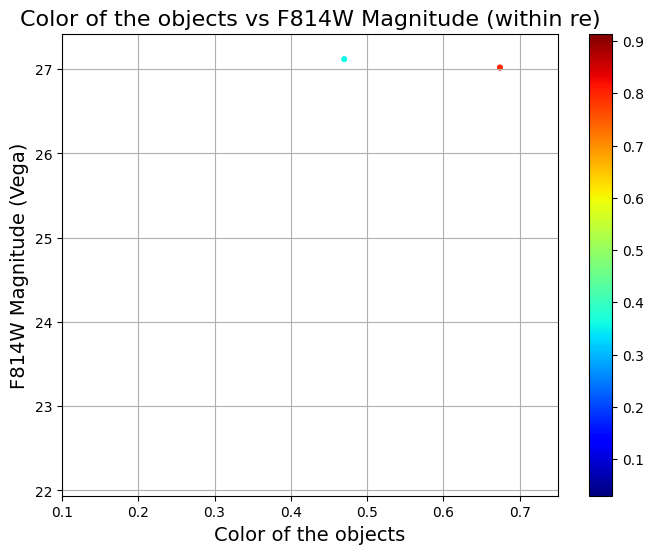

In [132]:
#plotting a color vs magnitude for the objects within a re
plt.figure(figsize=(8,6))

plt.scatter(color0, f814mag_re0, c = distgal_re0_n,cmap = 'jet', s=10)
plt.title('Color of the objects vs F814W Magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('F814W Magnitude (Vega)', fontsize=14)
plt.xlim(0.1, 0.75)
plt.grid()
plt.colorbar()
plt.scatter(color0, f814mag_re0, c = distgal_re0_n,cmap = 'jet', s=10)
plt.show()

In [129]:
#Converting into absolute Mag
distgalpc0 = 11.1 * 1e6
absmag_re0 = f814mag_re0 - 5*np.log10(distgalpc0/10)

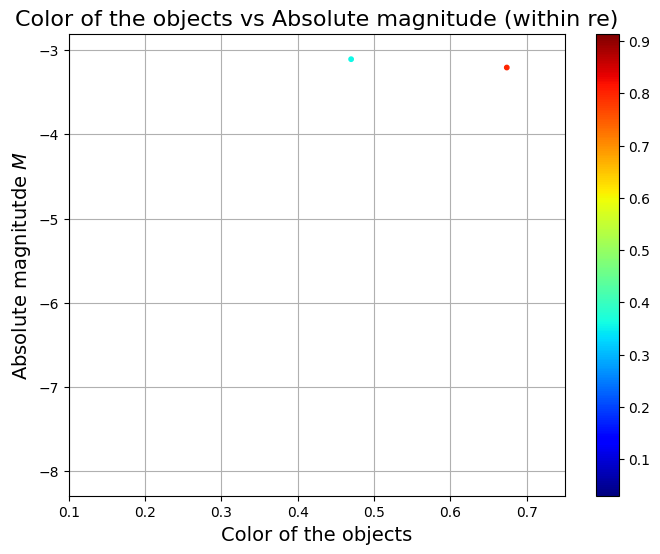

In [19]:
#plotting a color vs absolute magnitude for the objects within a re
plt.figure(figsize=(8,6))
plt.scatter(color0, absmag_re0, c = distgal_re0_n,cmap = 'jet', s=10)
plt.title('Color of the objects vs Absolute magnitude (within re)', fontsize=16)
plt.xlabel('Color of the objects', fontsize=14) 
plt.ylabel('Absolute magnitutde $M$', fontsize=14)
plt.xlim(0.1, 0.75)
plt.grid()
plt.colorbar()
plt.show()

In [20]:
#finding the mag of the object in 0.2 re
repixelsp20 = re_pixels0 * 0.2
print(repixelsp20)
f814mag_rep20 = f814mag0[distgal0 <= repixelsp20]

37.24000000000002


In [21]:
#Finding the mag difference of objects in 1 re then 0.2 re
max_mag_diff(f814mag_re0)# 1 re
max_mag_diff(f814mag_rep20)# 0.2 re

 The magnitude difference between the brightest and 2nd brightest object is -3.4549999999999983
 The magnitude difference between the brightest and 2nd brightest object is -3.4549999999999983


In [23]:
# adding concentration index to the catalog
newconcent0 = cut_cat0['newconcent']

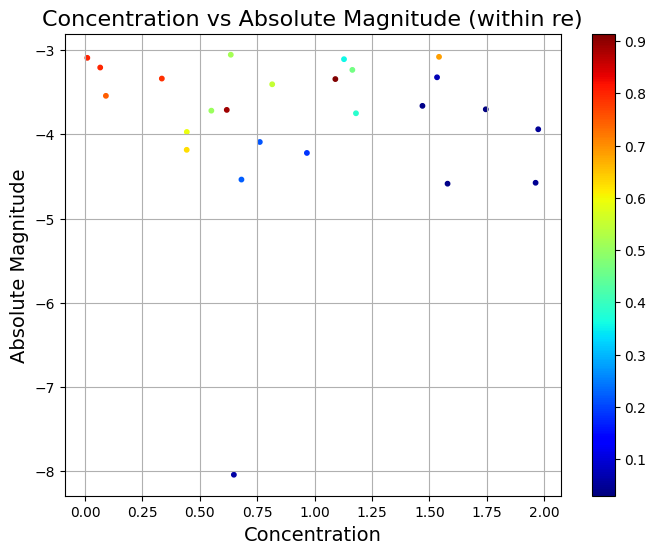

In [24]:
#Plotting the concentration vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent0[distgal0 <= re_pixels0], absmag_re0, c = distgal_re0_n,cmap = 'jet', s=10)
plt.title('Concentration vs Absolute Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration', fontsize=14) 
plt.ylabel('Absolute Magnitude', fontsize=14)
plt.grid()
plt.colorbar()
plt.show()

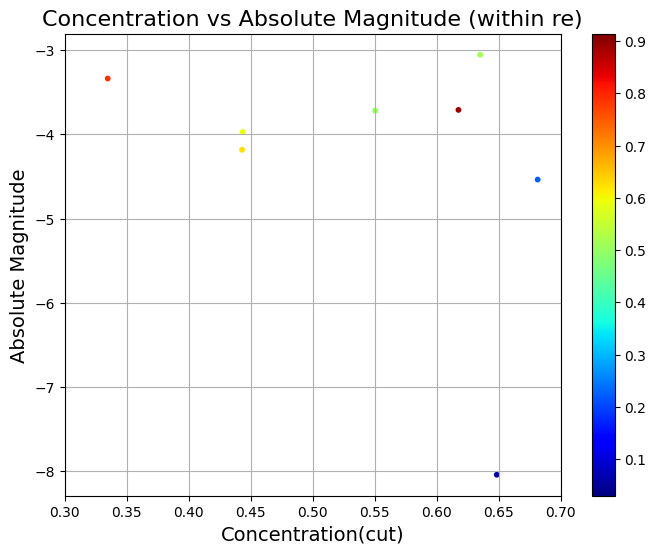

In [25]:
#Plotting the concentration(cut) vs Absolute magnitude graph withing 1 re
plt.figure(figsize=(8,6))
plt.scatter(newconcent0[distgal0 <= re_pixels0], absmag_re0, c = distgal_re0_n,cmap = 'jet', s=10)
plt.title('Concentration vs Absolute Magnitude (within re)', fontsize=16)
plt.xlabel('Concentration(cut)', fontsize=14) 
plt.ylabel('Absolute Magnitude', fontsize=14)
plt.xlim(0.3, 0.7)
plt.grid()
plt.colorbar()
plt.show()

In [43]:
# accessing the fits file to get the header and the wcs information
F814W0 = hdul0[1].data
F814W0header = hdul0[1].header



In [130]:
print(f814mag_re0)
print(distgal_re0)
print(newconcent0[distgal0 <= re_pixels0])
print(color0)

[22.186 25.652 26.287 26.524 26.565 25.641 25.69  26.477 26.043 26.255
 26.006 26.508 27.02  26.883 26.136 26.992 26.684 26.517 26.889 27.135
 27.119 26.821 27.172 26.904 27.147]
[ 11.30323301   8.25892843   9.32840279   5.57826958   6.88580207
   6.87203571  41.03887356  71.16830853 116.43847146 110.26764639
  34.81197668  93.77061608 148.54332638 170.19050041  39.78423494
  85.96882656 139.0579298  165.18633696 146.50450998 149.37463967
  66.26160957 102.40798702  96.22077267  13.54126996 127.11542049]
298      0.648385
426      1.962563
1684     1.974052
2592     1.745580
6329     1.469741
12975    1.579103
14815    0.681371
17722    1.180175
21076    0.442949
21557    0.443447
22225    0.966463
23781    0.550326
25146    0.066223
26824    1.090408
27893    0.761350
34750    1.164457
39542    0.090997
41086    0.617472
43375    0.334639
47204    0.010097
47936    1.128081
52720    0.815317
52994    0.634946
56502    1.533284
64038    1.541954
Name: newconcent, dtype: float64
[ 4.977

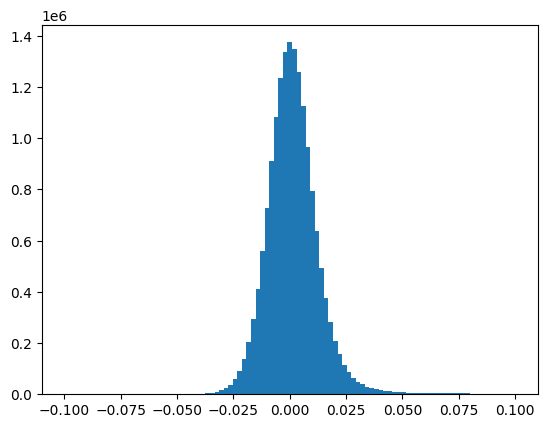

In [ ]:
# Checking the distribution of pixel values in the F814W image
plt.hist(F814W0.ravel(),np.linspace(-0.1,0.1, 100))
plt.show()

# information on the target object
Absmag = -8.04061489, Appmag = 22.186, distance from the identified galactic center = 11.30323301 pixels, index of the object on the catalog is 27, concentration = 0.648385, color = 4.977

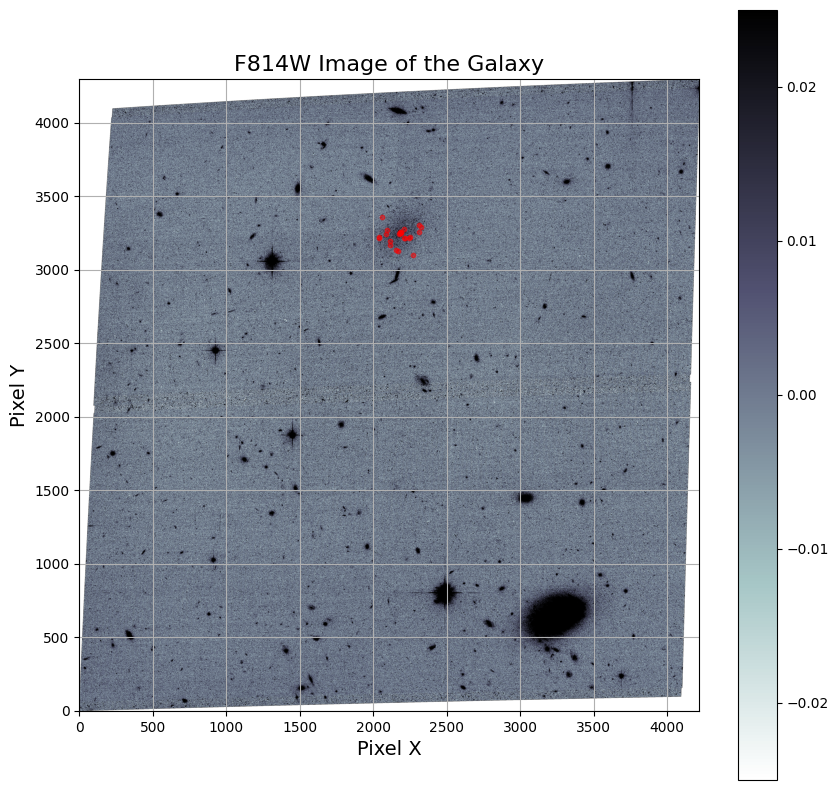

In [155]:
#Plotting the F814W image for the galaxy and overplot all the bright objects within re

fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=10, alpha = 0.5, label='Bright objects within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('Pixel X', fontsize=14)
plt.ylabel('Pixel Y', fontsize=14)
plt.grid()
plt.show()



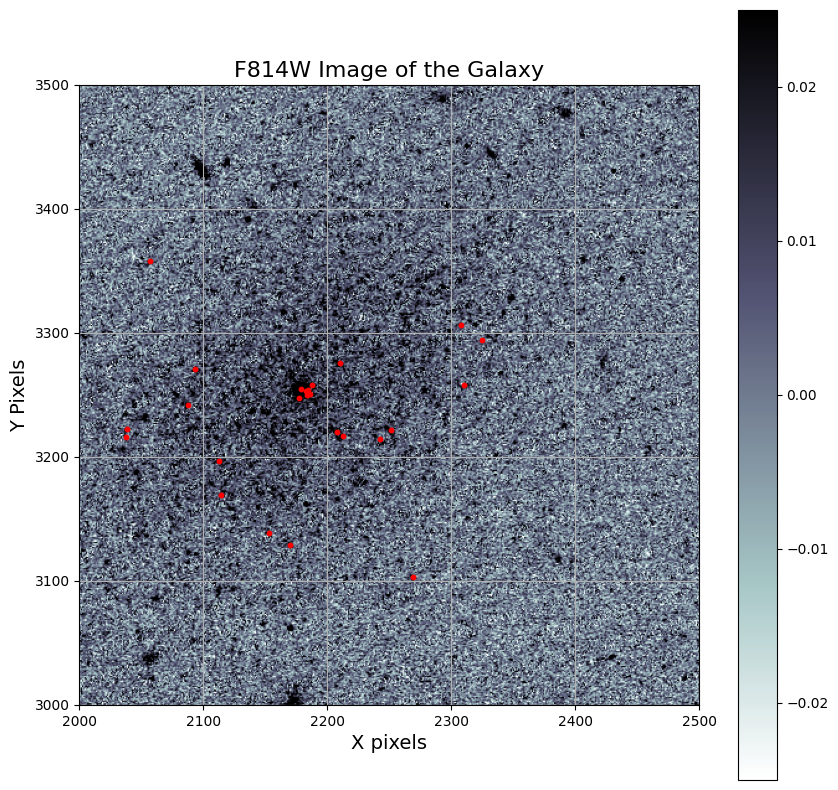

In [154]:
# zooming in for better visualization of the bright objects within re
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=10, label='Bright objects within re')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y Pixels', fontsize=14)
plt.xlim(2000, 2500)
plt.ylim(3000, 3500)
plt.grid()
plt.show()

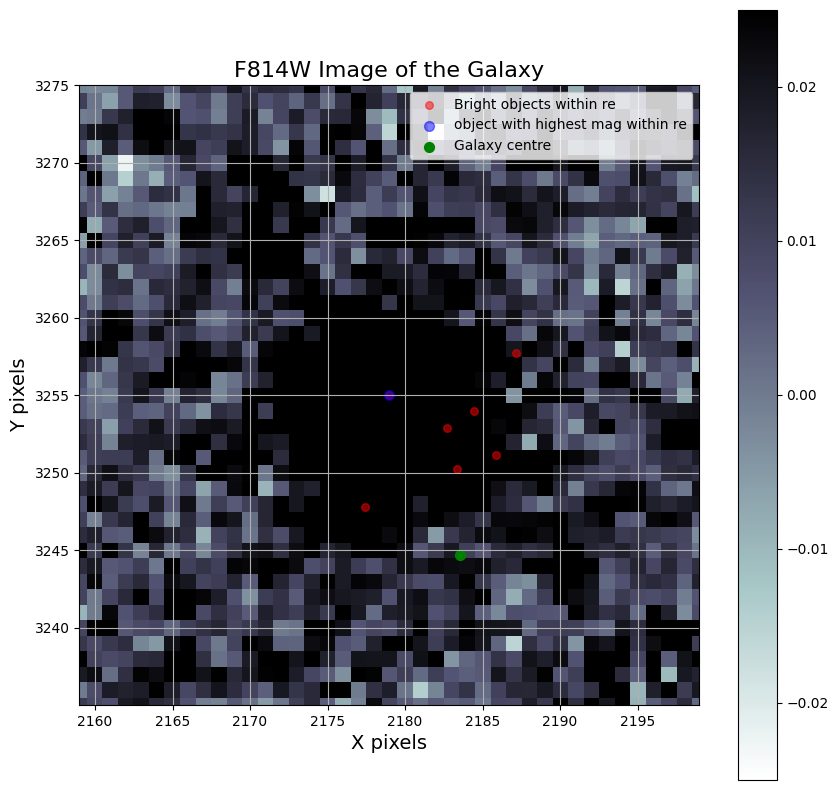

In [153]:
# zooming in even more to see the brightest and closest object to the centre of the galaxy
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.025, vmax = 0.025)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(xcgal0[27,], ycgal0[27,], color='blue', s=50, alpha = 0.5, label='object with highest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixels', fontsize=14)
plt.ylabel('Y pixels', fontsize=14)
plt.xlim(xcgal0[27]-20, xcgal0[27]+20)
plt.ylim(ycgal0[27]-20, ycgal0[27]+20)
plt.legend()
plt.grid()
plt.show()

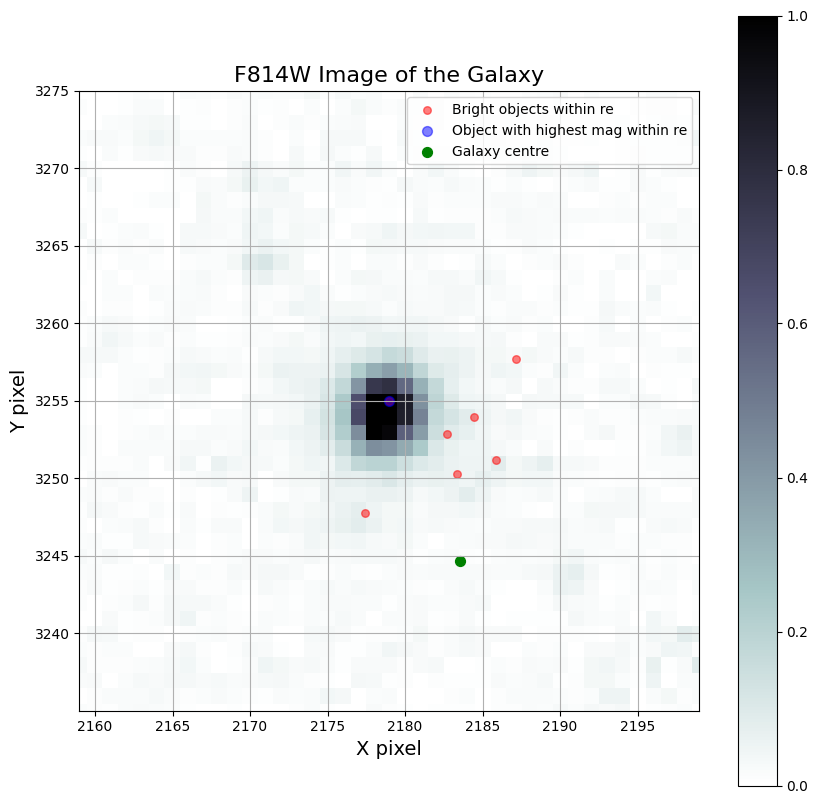

In [152]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = 0, vmax = 1)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(xcgal0[27,], ycgal0[27,], color='blue', s=50, alpha = 0.5, label='Object with highest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(xcgal0[27]-20, xcgal0[27]+20)
plt.ylim(ycgal0[27]-20, ycgal0[27]+20)
plt.legend()
plt.grid()
plt.show()

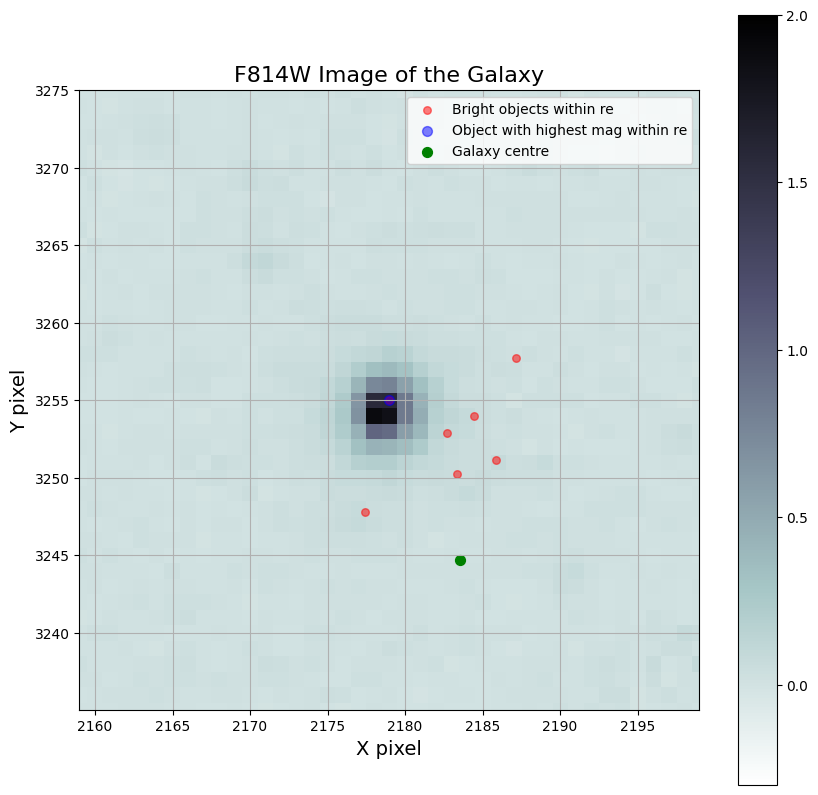

In [156]:
# trying to see how bright it is
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.3, vmax = 2)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(xcgal0[27,], ycgal0[27,], color='blue', s=50, alpha = 0.5, label='Object with highest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(xcgal0[27]-20, xcgal0[27]+20)
plt.ylim(ycgal0[27]-20, ycgal0[27]+20)
plt.legend()
plt.grid()
plt.show()

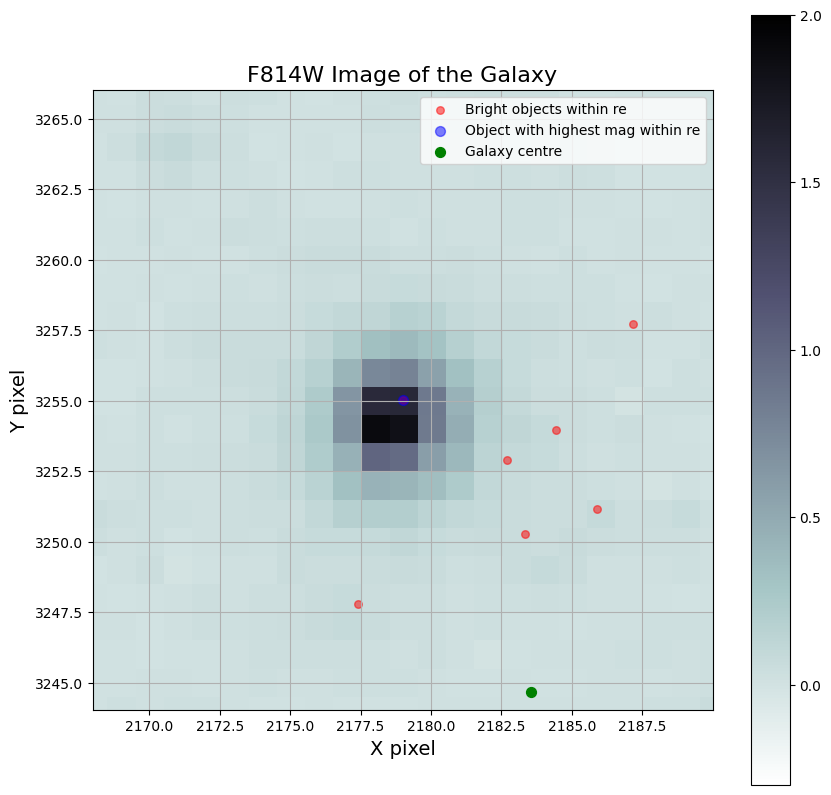

In [158]:
# Zooming in even more
fig0 = plt.figure(figsize=(10,10))
plt.imshow(F814W0, origin='lower', cmap='bone_r', vmin = -0.3, vmax = 2)
plt.colorbar()
plt.scatter(xcgal0[distgal0 <= re_pixels0], ycgal0[distgal0 <= re_pixels0], color='red', s=30, alpha = 0.5, label='Bright objects within re')
plt.scatter(xcgal0[27,], ycgal0[27,], color='blue', s=50, alpha = 0.5, label='Object with highest mag within re')
plt.scatter(galcenx0, galceny0, color='green', s=50, alpha = 1, label='Galaxy centre')
plt.title('F814W Image of the Galaxy', fontsize=16)
plt.xlabel('X pixel', fontsize=14)
plt.ylabel('Y pixel', fontsize=14)
plt.xlim(xcgal0[27]-11, xcgal0[27]+11)
plt.ylim(ycgal0[27]-11, ycgal0[27]+11)
plt.legend()
plt.grid()
plt.show()

# conclusion
Looks like it might be an extended source due to how bright the surroundind pixels also are